In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
features = df[
    [
        "Tenure_Months",
        "Monthly_Charges",
        "Total_Charges",
        "CLTV"
    ]
]

In [4]:
scaler = StandardScaler()

scaled = scaler.fit_transform(features)

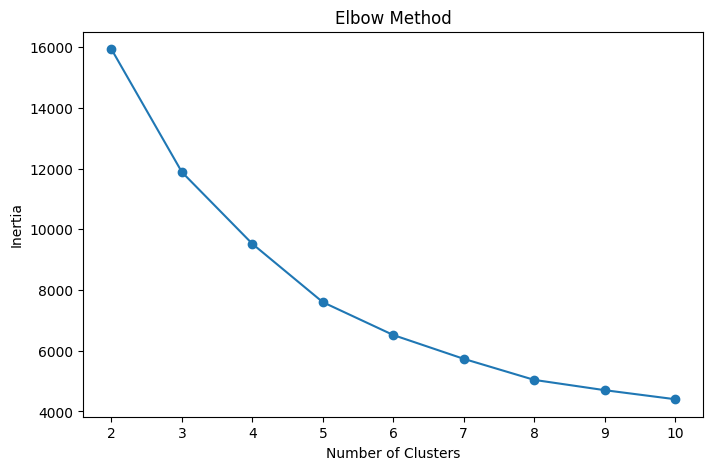

In [5]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [6]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled)

df["Cluster"] = clusters

In [7]:
score = silhouette_score(
    scaled,
    clusters
)

print(score)

0.3410959206318885


In [8]:
df.groupby("Cluster")[
[
"Tenure_Months",
"Monthly_Charges",
"Total_Charges",
"CLTV"
]
].mean()

,Tenure_Months,Monthly_Charges,Total_Charges,CLTV
Cluster,,,,
0,59.188413,93.191232,5506.533090,5100.521399
1,11.036410,57.687872,689.461859,4972.250256
2,17.553044,61.045157,1105.806365,2940.765683
3,54.518335,32.433053,1763.314866,5101.304262


In [9]:
pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

plot_df = pd.DataFrame()

plot_df["PC1"] = components[:,0]
plot_df["PC2"] = components[:,1]
plot_df["Cluster"] = clusters

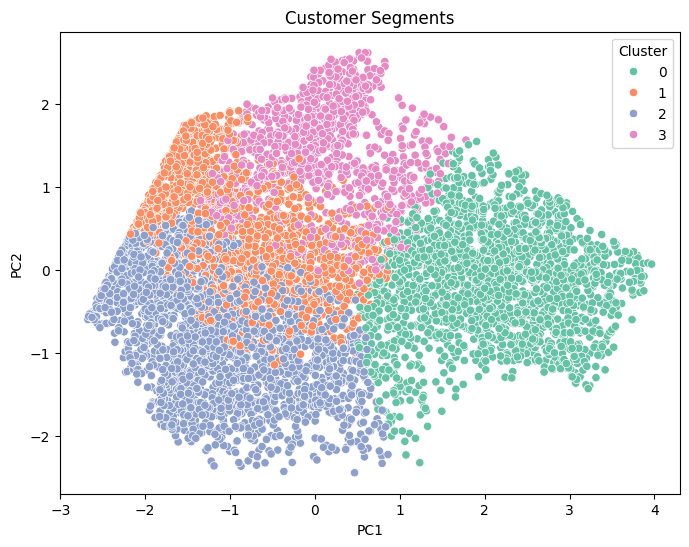

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

Cluster 0
High tenure
High CLTV
Premium loyal customers

Cluster 1
Low tenure
High churn risk

Cluster 2
Average customers

Cluster 3
High monthly charges
Upsell opportunity